# HaGRID Gesture Classifier

Layer 3b of the vision pipeline. 18 classes, 64x64 hand crops, from-scratch CNN.

In [1]:
import os, json, math, random, hashlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {device}")

device: mps


In [3]:
DATA_ROOT = "training data/hagrid-sample-30k-384p"
ANN_DIR   = f"{DATA_ROOT}/ann_train_val"
IMG_ROOT  = f"{DATA_ROOT}/hagrid_30k"
IMG_DIR_PREFIX = "train_val_"

CLASS_NAMES = [
    "call", "dislike", "fist", "four", "like", "mute", "ok", "one",
    "palm", "peace", "peace_inverted", "rock", "stop", "stop_inverted",
    "three", "three2", "two_up", "two_up_inverted",
]
NUM_CLASSES = 18
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IMG_SIZE = 64

CKPT_DIR = "checkpoints"
CKPT_PATH = f"{CKPT_DIR}/gesture_classifier_best.pt"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

assert len(CLASS_NAMES) == NUM_CLASSES
assert Path(ANN_DIR).is_dir(), f"missing {ANN_DIR} — is the working directory HAND_JOB?"
assert Path(IMG_ROOT).is_dir(), f"missing {IMG_ROOT}"
print("config ok")

config ok


In [4]:
def build_index():
    """Returns list of (img_path: str, bbox_xywh_norm: tuple, label_idx: int, user_id: str)."""
    rows = []
    dropped_no_gesture = 0
    dropped_missing_file = 0
    for cls in CLASS_NAMES:
        ann_path = Path(ANN_DIR) / f"{cls}.json"
        img_dir  = Path(IMG_ROOT) / f"{IMG_DIR_PREFIX}{cls}"
        with open(ann_path) as f:
            data = json.load(f)
        for image_id, meta in data.items():
            img_path = img_dir / f"{image_id}.jpg"
            if not img_path.is_file():
                dropped_missing_file += 1
                continue
            for bbox, label in zip(meta["bboxes"], meta["labels"]):
                if label == "no_gesture":
                    dropped_no_gesture += 1
                    continue
                if label not in CLASS_TO_IDX:
                    # stray label we do not know about — skip
                    continue
                rows.append((str(img_path), tuple(bbox), CLASS_TO_IDX[label], meta["user_id"]))
    print(f"rows: {len(rows)} | dropped no_gesture: {dropped_no_gesture} | dropped missing_file: {dropped_missing_file}")
    return rows

rows = build_index()

rows: 31832 | dropped no_gesture: 7052 | dropped missing_file: 477490


In [5]:
label_counts = Counter(r[2] for r in rows)
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:18s} {label_counts[i]:>5}")
print(f"total: {sum(label_counts.values())}")

  call                1763
  dislike             1783
  fist                1734
  four                1805
  like                1732
  mute                1811
  ok                  1750
  one                 1778
  palm                1770
  peace               1769
  peace_inverted      1742
  rock                1736
  stop                1748
  stop_inverted       1803
  three               1751
  three2              1737
  two_up              1855
  two_up_inverted     1765
total: 31832


In [6]:
def user_split(rows, train_pct=0.8, val_pct=0.1, seed=SEED):
    """Group by user_id. Deterministic assignment via hash+seed."""
    user_ids = sorted({r[3] for r in rows})
    rng = random.Random(seed)
    rng.shuffle(user_ids)
    n = len(user_ids)
    n_train = int(n * train_pct)
    n_val   = int(n * val_pct)
    train_users = set(user_ids[:n_train])
    val_users   = set(user_ids[n_train:n_train + n_val])
    test_users  = set(user_ids[n_train + n_val:])

    train = [r for r in rows if r[3] in train_users]
    val   = [r for r in rows if r[3] in val_users]
    test  = [r for r in rows if r[3] in test_users]

    # sanity
    assert train_users.isdisjoint(val_users)
    assert train_users.isdisjoint(test_users)
    assert val_users.isdisjoint(test_users)
    return train, val, test, (train_users, val_users, test_users)

train_rows, val_rows, test_rows, (train_u, val_u, test_u) = user_split(rows)
print(f"users  train/val/test: {len(train_u)} / {len(val_u)} / {len(test_u)}")
print(f"rows   train/val/test: {len(train_rows)} / {len(val_rows)} / {len(test_rows)}")

users  train/val/test: 6377 / 797 / 798
rows   train/val/test: 25309 / 3457 / 3066


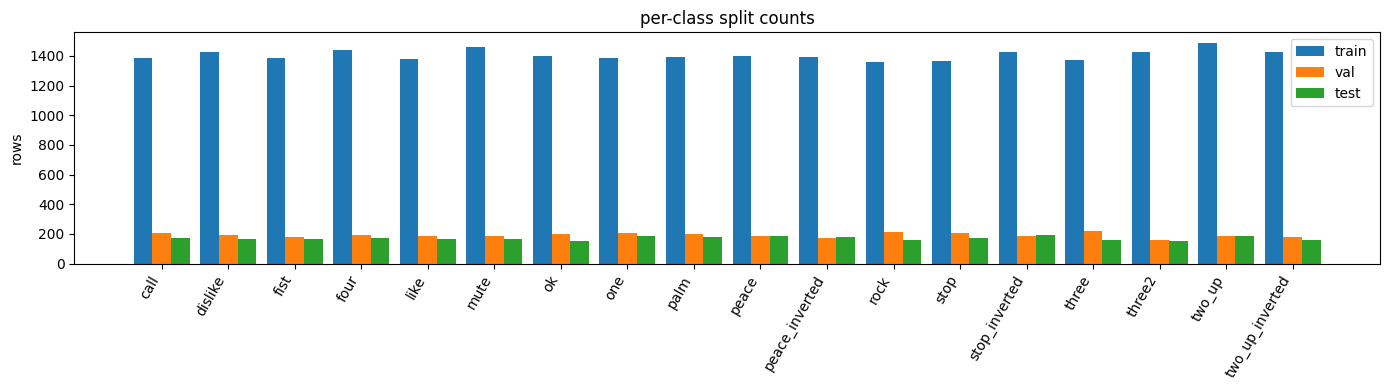

In [7]:
def split_class_counts(split_rows):
    c = Counter(r[2] for r in split_rows)
    return [c[i] for i in range(NUM_CLASSES)]

tr_c = split_class_counts(train_rows)
va_c = split_class_counts(val_rows)
te_c = split_class_counts(test_rows)

x = np.arange(NUM_CLASSES)
w = 0.28
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x - w, tr_c, w, label="train")
ax.bar(x,     va_c, w, label="val")
ax.bar(x + w, te_c, w, label="test")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=60, ha="right")
ax.set_ylabel("rows"); ax.legend(); ax.set_title("per-class split counts")
plt.tight_layout(); plt.show()

for i, c in enumerate(CLASS_NAMES):
    if va_c[i] < 50 or te_c[i] < 50:
        print(f"WARN: {c} has low eval count (val={va_c[i]}, test={te_c[i]})")

In [8]:
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    T.RandomPerspective(distortion_scale=0.15, p=0.5),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
print("transforms built")

transforms built


In [9]:
class HagridGestureDataset(Dataset):
    """Crop hand via HaGRID bbox with padding jitter, resize to IMG_SIZE, apply transforms."""
    def __init__(self, rows, mode: str):
        assert mode in ("train", "eval")
        self.rows = rows
        self.mode = mode
        self.tf = train_tf if mode == "train" else eval_tf

    def __len__(self):
        return len(self.rows)

    def _padded_crop(self, img: Image.Image, bbox_norm):
        W, H = img.size
        x, y, w, h = bbox_norm
        px, py = x * W, y * H
        pw, ph = w * W, h * H
        side = max(pw, ph)
        if self.mode == "train":
            pad_frac = random.uniform(0.05, 0.25)
        else:
            pad_frac = 0.15
        pad = side * pad_frac
        x0 = max(0, int(px - pad))
        y0 = max(0, int(py - pad))
        x1 = min(W, int(px + pw + pad))
        y1 = min(H, int(py + ph + pad))
        if x1 <= x0 or y1 <= y0:
            # degenerate bbox — return full image rather than crash
            return img
        return img.crop((x0, y0, x1, y1))

    def __getitem__(self, idx):
        img_path, bbox_norm, label_idx, _ = self.rows[idx]
        img = Image.open(img_path).convert("RGB")
        crop = self._padded_crop(img, bbox_norm)
        return self.tf(crop), label_idx

In [10]:
_smoke = HagridGestureDataset(train_rows[:8], mode="train")
_x, _y = _smoke[0]
print("tensor:", _x.shape, _x.dtype, "label:", _y, CLASS_NAMES[_y])
assert tuple(_x.shape) == (3, IMG_SIZE, IMG_SIZE)

tensor: torch.Size([3, 64, 64]) torch.float32 label: 0 call


In [11]:
BATCH = 128

train_ds = HagridGestureDataset(train_rows, mode="train")
val_ds   = HagridGestureDataset(val_rows,   mode="eval")
test_ds  = HagridGestureDataset(test_rows,  mode="eval")

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, yb.shape, "labels sample:", yb[:8].tolist())

batch: torch.Size([128, 3, 64, 64]) torch.Size([128]) labels sample: [10, 3, 2, 9, 12, 14, 13, 14]


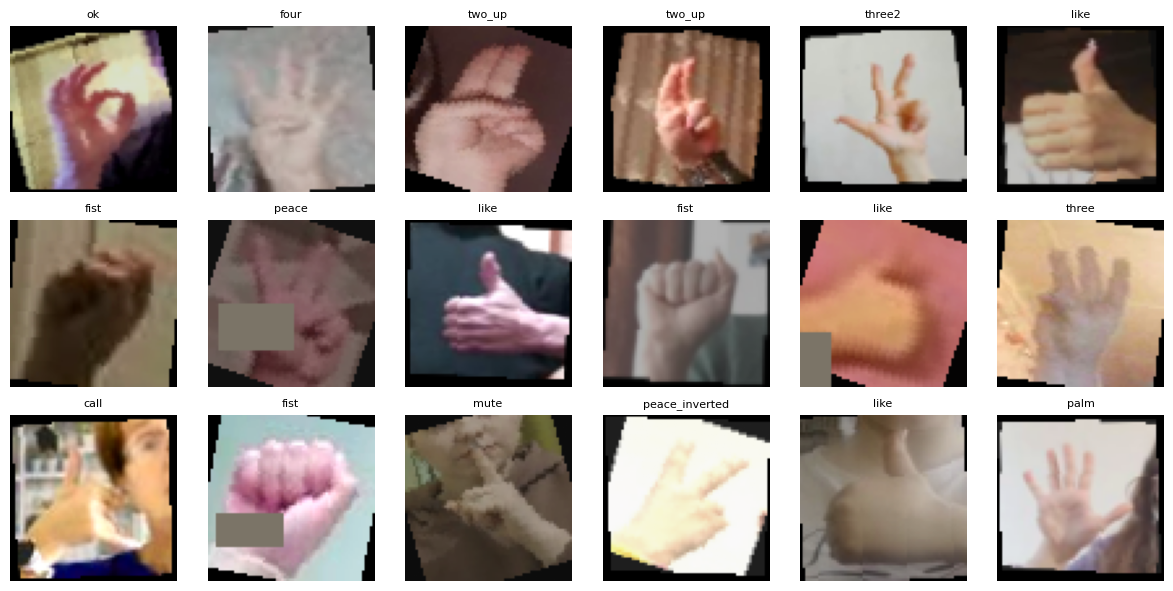

In [12]:
def _denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * s + m).clamp(0, 1)

xb, yb = next(iter(train_loader))
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = _denorm(xb[i]).permute(1, 2, 0).numpy()
    ax.imshow(img); ax.set_title(CLASS_NAMES[yb[i].item()], fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

In [13]:
class GestureNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Dropout2d(0.1), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Dropout2d(0.1), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Dropout2d(0.1), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.features(x))

In [14]:
model = GestureNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"params: {n_params:,}")
with torch.no_grad():
    _out = model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=device))
print("output shape:", _out.shape)
assert tuple(_out.shape) == (2, NUM_CLASSES)

params: 131,346
output shape: torch.Size([2, 18])


## Task 10: Training + eval functions

In [15]:
# Task 10 — class-weighted loss
train_label_counts = np.zeros(NUM_CLASSES, dtype=np.float64)
for _, _, li, _ in train_rows:
    train_label_counts[li] += 1
class_weights = 1.0 / np.sqrt(train_label_counts)
class_weights = class_weights / class_weights.mean()  # center around 1.0
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("class weights min/max:", class_weights.min(), class_weights.max())

criterion = nn.CrossEntropyLoss(weight=class_weights_t)

class weights min/max: 0.9731913193220981 1.0162162009192977


In [16]:
# Task 10 — train/eval helpers
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_n = 0.0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        total_n += x.size(0)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_labels.append(y.cpu().numpy())
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    return {
        "loss": total_loss / total_n,
        "acc":  accuracy_score(labels, preds),
        "f1":   f1_score(labels, preds, average="macro", zero_division=0),
        "preds": preds,
        "labels": labels,
    }

def train_one_epoch(model, loader, opt):
    model.train()
    total_loss, total_n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * x.size(0)
        total_n += x.size(0)
    return total_loss / total_n

In [17]:
# Task 10 — smoke step
_opt = torch.optim.Adam(model.parameters(), lr=3e-4)
_xb, _yb = next(iter(train_loader))
_xb, _yb = _xb.to(device), _yb.to(device)
_opt.zero_grad(); _loss = criterion(model(_xb), _yb); _loss.backward(); _opt.step()
print("smoke loss:", _loss.item())

smoke loss: 3.680009126663208


## Task 11: Training loop with checkpointing and early stopping

In [18]:
# Task 11 Step 1 — training config + reset model
EPOCHS = 30
LR = 3e-4
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 6

# fresh model for the real run (smoke test above already stepped the old one)
model = GestureNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
best_f1 = -1.0
epochs_since_improve = 0
os.makedirs(CKPT_DIR, exist_ok=True)
print("model reset, optimizer and scheduler ready")

model reset, optimizer and scheduler ready


In [ ]:
for epoch in range(EPOCHS):
    tr_loss = train_one_epoch(model, train_loader, optimizer)
    val = evaluate(model, val_loader)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val["loss"])
    history["val_acc"].append(val["acc"])
    history["val_f1"].append(val["f1"])

    improved = val["f1"] > best_f1
    if improved:
        best_f1 = val["f1"]
        epochs_since_improve = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": CLASS_NAMES,
            "img_size": IMG_SIZE,
            "normalize_mean": IMAGENET_MEAN,
            "normalize_std":  IMAGENET_STD,
            "val_macro_f1": best_f1,
            "epoch": epoch,
        }, CKPT_PATH)
    else:
        epochs_since_improve += 1

    flag = " *" if improved else ""
    print(f"epoch {epoch:2d} | tr_loss {tr_loss:.4f} | val_loss {val['loss']:.4f} | "
          f"val_acc {val['acc']:.4f} | val_f1 {val['f1']:.4f}{flag}")

    if epochs_since_improve >= EARLY_STOP_PATIENCE:
        print(f"early stop at epoch {epoch} (no val_f1 improvement in {EARLY_STOP_PATIENCE} epochs)")
        break

print(f"best val macro-F1: {best_f1:.4f}")